# Network communities vs. true allegiance



We build the character network from `characters_enriched.csv` (edges from the `affiliated` column, exactly as in `network.ipynb`), run **Louvain community detection** to obtain *network labels*, and compare them to the *true labels* given by each character's primary `allegiance` (their first listed house).



The question: **does the connection structure of the world recover the house affiliations?**



We answer it three ways:

1. global agreement scores (Adjusted Rand Index, NMI, V-measure)

2. a confusion matrix between Louvain communities and the top houses

3. per-community purity and the dominant house in each community



The Louvain pipeline (and the degree-preserving null model) is taken from `Week6/exercise4.ipynb`.

In [41]:
from collections import Counter, defaultdict
from community import community_louvain
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
from tqdm import tqdm
import networkx as nx
import pandas as pd
import numpy as np
import random

from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    homogeneity_completeness_v_measure,
    confusion_matrix,
)

random.seed(42)
np.random.seed(42)

## 1. Build the character network



Same construction as `network.ipynb`: an undirected edge between *A* and *B* iff *B* appears in *A*'s `affiliated` list **and** *B* is also a known character ID.

In [42]:
df = pd.read_csv('../csvs/characters_enriched_v3.csv').fillna('')
valid_ids = set(df['ID'])
print(f'Characters in dataset: {len(valid_ids)}')
df.head(3) 

Characters in dataset: 3690


,name,ID,father,mother,spouse,lover,issue,allegiance,affiliated
0,A certain man,A_certain_man,,,,,,,Tyrion_Lannister;Varys;Stannis_Baratheon;Cortn...
1,Abelar Hightower,Abelar_Hightower,,,,,,House_Hightower,Valarr_Targaryen
2,Abelon,Abelon,,,,,,Citadel,


In [43]:
edges = set()
for _, row in df.iterrows():
    src = row['ID']
    if not row['affiliated']:
        continue
    for tgt in row['affiliated'].split(';'):
        tgt = tgt.strip()
        if tgt and tgt != src and tgt in valid_ids:
            edges.add(frozenset({src, tgt}))

G = nx.Graph()
G.add_nodes_from(df['ID'])
G.add_edges_from(tuple(e) for e in edges)

# attach attributes for later styling
name_by_id = dict(zip(df['ID'], df['name']))
primary_house = {
    row['ID']: (row['allegiance'].split(';')[0].strip() if row['allegiance'] else '')
    for _, row in df.iterrows()
}
nx.set_node_attributes(G, name_by_id, 'name')
nx.set_node_attributes(G, primary_house, 'house')

print(f'Nodes: {G.number_of_nodes()}, Edges: {G.number_of_edges()}')

Nodes: 3690, Edges: 17169


Louvain only really makes sense on the connected part of the graph (isolated characters get singleton communities that drown out everything else). We restrict to the **largest connected component** for the rest of the notebook.

In [44]:
components = sorted(nx.connected_components(G), key=len, reverse=True)
LCC = G.subgraph(components[0]).copy()
print(f'LCC nodes: {LCC.number_of_nodes()}, LCC edges: {LCC.number_of_edges()}')
print(f'Fraction of full graph in LCC: {LCC.number_of_nodes() / G.number_of_nodes():.2%}')

LCC nodes: 3046, LCC edges: 17057
Fraction of full graph in LCC: 82.55%


## 2. Louvain community detection — *network labels*



Report the number of communities, their sizes, and the modularity.

In [45]:
partition = community_louvain.best_partition(LCC, random_state=42)

num_communities = max(partition.values()) + 1
community_sizes = Counter(partition.values())

print(f'Number of communities: {num_communities}')
print('\nTop 15 community sizes:')
for comm_id, size in community_sizes.most_common(15):
    print(f'  Community {comm_id}: {size} nodes')

Number of communities: 15

Top 15 community sizes:
  Community 5: 471 nodes
  Community 0: 440 nodes
  Community 13: 434 nodes
  Community 2: 384 nodes
  Community 9: 329 nodes
  Community 7: 307 nodes
  Community 1: 267 nodes
  Community 8: 178 nodes
  Community 4: 128 nodes
  Community 3: 27 nodes
  Community 14: 24 nodes
  Community 12: 22 nodes
  Community 11: 17 nodes
  Community 10: 13 nodes
  Community 6: 5 nodes


In [46]:
modularity = community_louvain.modularity(partition, LCC)
print(f'Modularity (Louvain): {modularity:.4f}')

Modularity (Louvain): 0.6327


## 3. Is the modularity significantly different from 0?



Degree-preserving edge swaps build a null distribution; same procedure as the Week 6 exercise.

In [47]:
def double_edge_swap(G, seed=None):
    """Degree-preserving randomization using NetworkX' built-in swap.

    Much faster than a hand-rolled loop because it uses internal
    adjacency dicts instead of O(E) list.remove() calls.
    """
    G_copy = G.copy()
    E = G_copy.number_of_edges()
    nx.double_edge_swap(G_copy, nswap=E * 2, max_tries=E * 20, seed=seed)
    return G_copy


In [48]:
random_modularities = []
for i in tqdm(range(20), desc='null model'):
    G_rand = double_edge_swap(LCC, seed=i)
    rand_partition = community_louvain.best_partition(G_rand, random_state=i)
    random_modularities.append(community_louvain.modularity(rand_partition, G_rand))

mu, sigma = float(np.mean(random_modularities)), float(np.std(random_modularities))
z = (modularity - mu) / sigma
print(f'Random modularity \u2014 mean: {mu:.4f}, std: {sigma:.4f}')
print(f'Actual modularity: {modularity:.4f}')
print(f'Z-score: {z:.2f}')


null model: 100%|██████████| 20/20 [00:12<00:00,  1.54it/s]

Random modularity — mean: 0.2382, std: 0.0020
Actual modularity: 0.6327
Z-score: 197.08


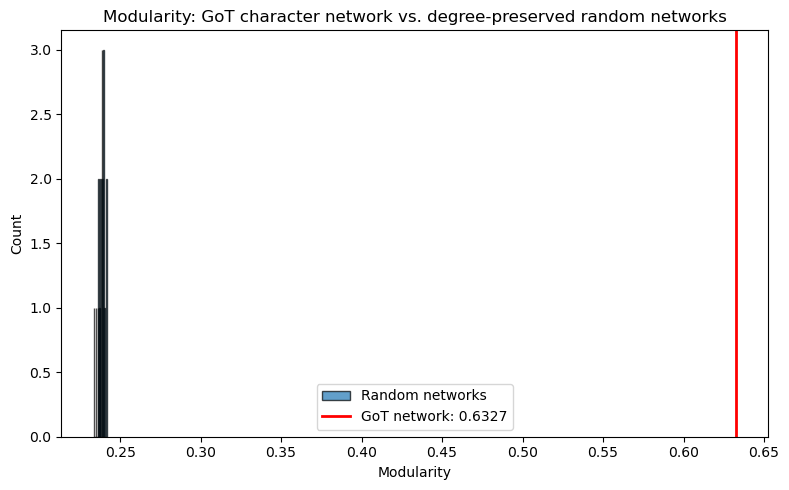

In [49]:
plt.figure(figsize=(8, 5))
plt.hist(random_modularities, bins=20, edgecolor='black', alpha=0.7, label='Random networks')
plt.axvline(modularity, color='red', linewidth=2, label=f'GoT network: {modularity:.4f}')
plt.xlabel('Modularity')
plt.ylabel('Count')
plt.title('Modularity: GoT character network vs. degree-preserved random networks')
plt.legend()
plt.tight_layout()
plt.show()

If the actual modularity sits far outside the null distribution, the community structure is real and not an artefact of the degree sequence.

## 4. *True labels*: primary house allegiance



Each character's first listed `allegiance` is treated as their canonical house. Characters without any allegiance can't be evaluated and are dropped from the comparison.

In [50]:
labelled = [n for n in LCC.nodes() if primary_house.get(n)]
coverage = len(labelled) / LCC.number_of_nodes()
print(f'LCC nodes with a known primary house: {len(labelled)} / {LCC.number_of_nodes()} ({coverage:.1%})')
if coverage < 0.5:
    print(f'\u26a0\ufe0f  WARNING: less than half of the LCC has a known allegiance \u2014 the comparison only covers {coverage:.0%} of the network.')
elif coverage < 0.75:
    print(f'\u2139\ufe0f  Note: {(1-coverage):.0%} of LCC nodes have no allegiance and are excluded from the agreement scores.')

house_counts = Counter(primary_house[n] for n in labelled)
print(f'\nDistinct houses among labelled nodes: {len(house_counts)}')
print('\nTop 15 houses:')
for h, c in house_counts.most_common(15):
    print(f'  {h}: {c}')


LCC nodes with a known primary house: 2598 / 3046 (85.3%)

Distinct houses among labelled nodes: 454

Top 15 houses:
  Citadel: 106
  Night's_Watch: 105
  House_Targaryen: 104
  House_Stark: 97
  House_Frey: 75
  Faith_of_the_Seven: 73
  House_Greyjoy: 66
  House_Lannister: 64
  Mance_Rayder: 54
  House_Martell: 46
  House_Hightower: 36
  House_Velaryon: 34
  House_Tyrell: 33
  House_Arryn: 30
  House_Baratheon: 28


## 5. Global agreement: ARI, NMI, V-measure



We line up two label vectors over the same set of nodes — Louvain community ID and primary house — and ask how much information one carries about the other.



* **Adjusted Rand Index (ARI)**: 0 ≈ random partition, 1 = identical. Adjusted for chance, so a graph with hundreds of tiny clusters can't cheat.

* **Normalized Mutual Information (NMI)**: 0 = independent, 1 = one fully determines the other. Symmetric.

* **Homogeneity / Completeness / V-measure**: are communities pure (one house each) and are houses kept together (one community each)?

In [51]:
y_true = [primary_house[n] for n in labelled]
y_pred = [partition[n] for n in labelled]

ari = adjusted_rand_score(y_true, y_pred)
nmi = normalized_mutual_info_score(y_true, y_pred)
hom, comp, vmeas = homogeneity_completeness_v_measure(y_true, y_pred)

print(f'Adjusted Rand Index : {ari:.4f}')
print(f'Normalized MI       : {nmi:.4f}')
print(f'Homogeneity         : {hom:.4f}   (are communities house-pure?)')
print(f'Completeness        : {comp:.4f}   (are houses kept together?)')
print(f'V-measure           : {vmeas:.4f}')

Adjusted Rand Index : 0.0567
Normalized MI       : 0.3564
Homogeneity         : 0.2544   (are communities house-pure?)
Completeness        : 0.5945   (are houses kept together?)
V-measure           : 0.3564


### Sanity check against a random baseline



Shuffle the community labels and re-score. If the real numbers aren't dramatically higher than this baseline, our Louvain communities aren't telling us anything about house structure.

In [52]:
shuffled = list(y_pred)
rng = random.Random(0)
rng.shuffle(shuffled)
print(f'Shuffled ARI: {adjusted_rand_score(y_true, shuffled):.4f}')
print(f'Shuffled NMI: {normalized_mutual_info_score(y_true, shuffled):.4f}')

Shuffled ARI: -0.0003
Shuffled NMI: 0.1636


## 6. Confusion matrix: communities × top houses



We restrict to the top houses (by population) and the largest communities, so the heatmap is readable. A clean diagonal-ish pattern would mean Louvain rediscovers house structure.

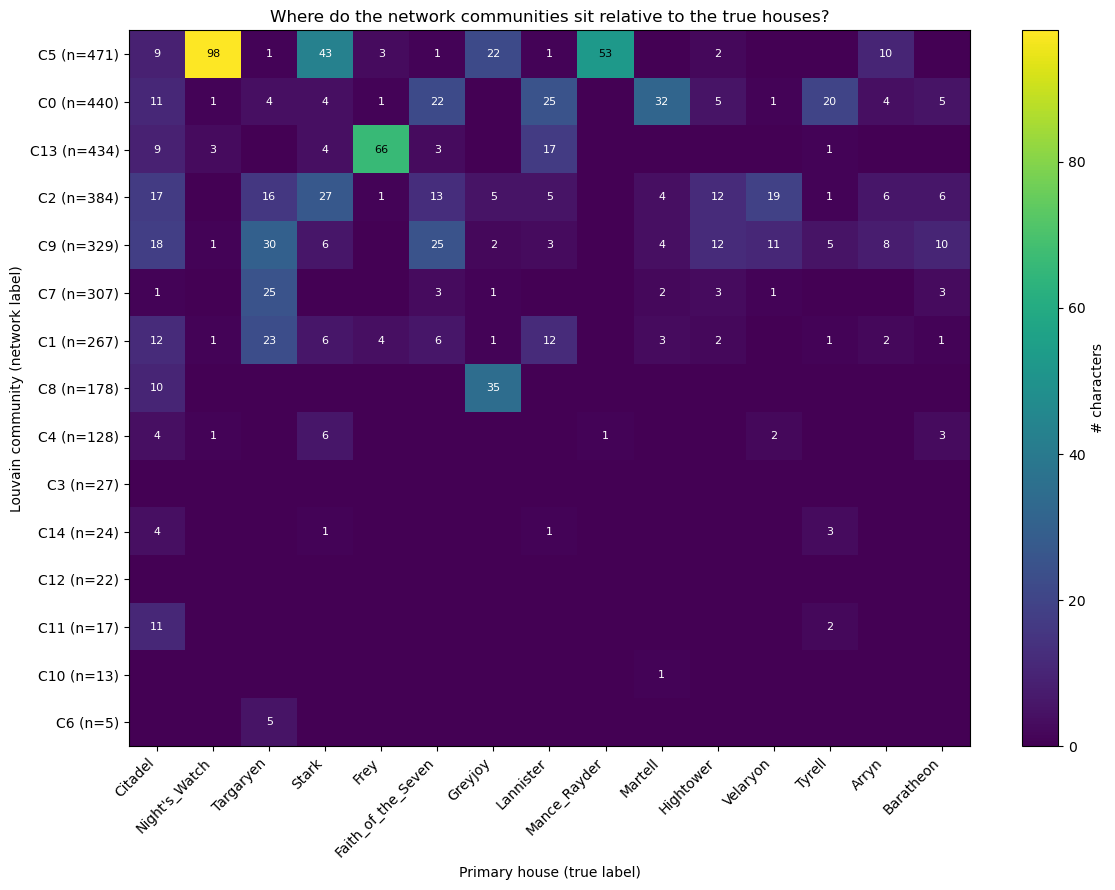

In [53]:
TOP_HOUSES = 15
TOP_COMMS = 15

top_houses = [h for h, _ in house_counts.most_common(TOP_HOUSES)]
top_comms = [c for c, _ in community_sizes.most_common(TOP_COMMS)]

M = np.zeros((len(top_comms), len(top_houses)), dtype=int)
house_idx = {h: i for i, h in enumerate(top_houses)}
comm_idx = {c: i for i, c in enumerate(top_comms)}

for n in labelled:
    h = primary_house[n]
    c = partition[n]
    if h in house_idx and c in comm_idx:
        M[comm_idx[c], house_idx[h]] += 1

fig, ax = plt.subplots(figsize=(12, 9))
im = ax.imshow(M, cmap='viridis', aspect='auto')
ax.set_xticks(range(len(top_houses)))
ax.set_xticklabels([h.replace('House_', '') for h in top_houses], rotation=45, ha='right')
ax.set_yticks(range(len(top_comms)))
ax.set_yticklabels([f'C{c} (n={community_sizes[c]})' for c in top_comms])
ax.set_xlabel('Primary house (true label)')
ax.set_ylabel('Louvain community (network label)')
ax.set_title('Where do the network communities sit relative to the true houses?')
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        if M[i, j] > 0:
            ax.text(j, i, str(M[i, j]), ha='center', va='center',
                    color='white' if M[i, j] < M.max() / 2 else 'black', fontsize=8)
plt.colorbar(im, ax=ax, label='# characters')
plt.tight_layout()
plt.show()

### Per-house purity: what % of each house lives in its dominant community?

The confusion matrix shows the joint distribution; this chart collapses each row of the *house* view into one number — `(# members in modal Louvain community) / (# members total)`. 100% means the house is perfectly contained in one community; lower values mean the network splits the house across multiple communities.

**Simpson's index** is shown alongside as an alternative purity measure: $\sum_i p_i^2$ where $p_i$ is the fraction of the house in community $i$. Concentration only cares about the top community; Simpson punishes every additional community a house is split into. A house at 60/40 has concentration 0.60 and Simpson 0.52; a house at 60/20/20 also has concentration 0.60 but Simpson 0.44.

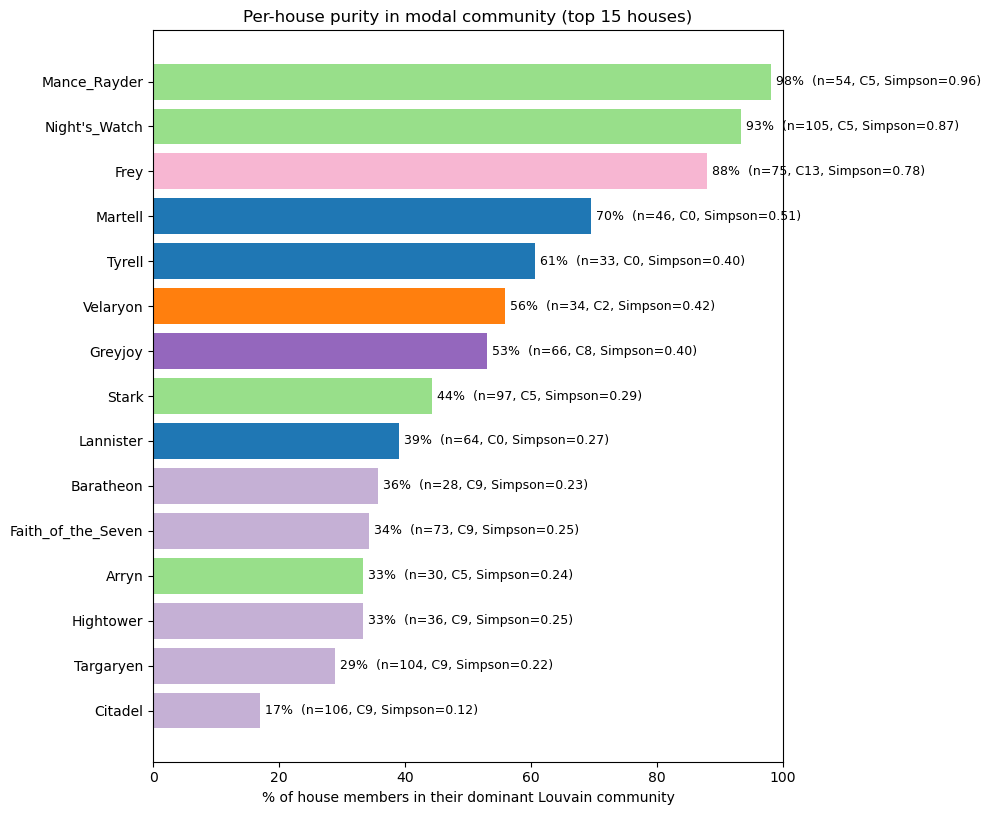


Sorted by concentration:
             house  members  dominant_community  in_dominant_pct  simpson  n_communities
      Mance_Rayder       54                   5        98.148148 0.963649              2
     Night's_Watch      105                   5        93.333333 0.872290              6
              Frey       75                  13        88.000000 0.779200              5
           Martell       46                   0        69.565217 0.505671              6
            Tyrell       33                   0        60.606061 0.404959              7
          Velaryon       34                   2        55.882353 0.422145              5
           Greyjoy       66                   8        53.030303 0.399449              6
             Stark       97                   5        44.329897 0.288979              8
         Lannister       64                   0        39.062500 0.267090              7
         Baratheon       28                   9        35.714286 0.229592           

In [54]:
purity_rows = []
for h in top_houses:
    members = [n for n in labelled if primary_house[n] == h]
    if not members:
        continue
    comms = Counter(partition[n] for n in members)
    dom_comm, dom_count = comms.most_common(1)[0]
    total = len(members)
    simpson = sum((c / total) ** 2 for c in comms.values())
    purity_rows.append({
        'house': h.replace('House_', ''),
        'members': total,
        'dominant_community': dom_comm,
        'in_dominant_pct': dom_count / total * 100,
        'simpson': simpson,
        'n_communities': len(comms),
    })

purity_df = pd.DataFrame(purity_rows).sort_values('in_dominant_pct', ascending=True)

fig, ax = plt.subplots(figsize=(10, 0.45 * len(purity_df) + 1.5))
comm_ids = purity_df['dominant_community'].to_numpy()
colors = plt.cm.tab20((comm_ids % 20) / 20.0)
bars = ax.barh(purity_df['house'], purity_df['in_dominant_pct'], color=colors)
for bar, row in zip(bars, purity_df.itertuples()):
    ax.text(bar.get_width() + 0.8, bar.get_y() + bar.get_height() / 2,
            f'{row.in_dominant_pct:.0f}%  (n={row.members}, C{row.dominant_community}, Simpson={row.simpson:.2f})',
            va='center', fontsize=9)
ax.set_xlim(0, 100)
ax.set_xlabel('% of house members in their dominant Louvain community')
ax.set_title(f'Per-house purity in modal community (top {len(purity_df)} houses)')
plt.tight_layout()
plt.show()

print('\nSorted by concentration:')
print(purity_df.sort_values('in_dominant_pct', ascending=False)
      [['house', 'members', 'dominant_community', 'in_dominant_pct', 'simpson', 'n_communities']]
      .to_string(index=False))

## 7. Per-community purity & dominant house



For each community: which house is most represented, and what fraction of the community does that house make up? **Purity** of a community is `max(house_count) / community_size` over labelled nodes only.

In [55]:
rows = []
for c in sorted(community_sizes, key=community_sizes.get, reverse=True):
    members = [n for n in labelled if partition[n] == c]
    if not members:
        continue
    houses = Counter(primary_house[n] for n in members)
    dom_house, dom_count = houses.most_common(1)[0]
    rows.append({
        'community': c,
        'size_total': community_sizes[c],
        'size_labelled': len(members),
        'dominant_house': dom_house,
        'dominant_count': dom_count,
        'purity': dom_count / len(members),
        'n_distinct_houses': len(houses),
    })

comm_summary = pd.DataFrame(rows)
comm_summary.head(20)

,community,size_total,size_labelled,dominant_house,dominant_count,purity,n_distinct_houses
0,5,471,412,Night's_Watch,98,0.237864,97
1,0,440,391,House_Martell,32,0.081841,133
2,13,434,345,House_Frey,66,0.191304,111
3,2,384,362,House_Stark,27,0.074586,135
4,9,329,302,House_Targaryen,30,0.099338,108
5,7,307,244,House_Targaryen,25,0.102459,87
6,1,267,230,House_Targaryen,23,0.100000,86
7,8,178,137,House_Greyjoy,35,0.255474,43
8,4,128,118,House_Baratheon_of_Dragonstone,14,0.118644,58
9,3,27,12,House_Blackwood,3,0.250000,7


In [56]:
# Weighted (by labelled size) average purity
weighted_purity = (comm_summary['purity'] * comm_summary['size_labelled']).sum() / comm_summary['size_labelled'].sum()
print(f'Weighted-average community purity: {weighted_purity:.3f}')
print(f'Median community purity:           {comm_summary["purity"].median():.3f}')

Weighted-average community purity: 0.145
Median community purity:           0.222


## 8. Per-house: are houses kept together by the network?



Flip the question: for each top house, how many distinct Louvain communities do its members spread across, and what fraction lives in the *most common* one?

In [57]:
rows = []
for h in top_houses:
    members = [n for n in labelled if primary_house[n] == h]
    if not members:
        continue
    comms = Counter(partition[n] for n in members)
    dom_comm, dom_count = comms.most_common(1)[0]
    rows.append({
        'house': h,
        'members': len(members),
        'n_distinct_communities': len(comms),
        'dominant_community': dom_comm,
        'concentration': dom_count / len(members),
    })

house_summary = pd.DataFrame(rows).sort_values('members', ascending=False)
house_summary

,house,members,n_distinct_communities,dominant_community,concentration
0,Citadel,106,11,9,0.169811
1,Night's_Watch,105,6,5,0.933333
2,House_Targaryen,104,7,9,0.288462
3,House_Stark,97,8,5,0.443299
4,House_Frey,75,5,13,0.880000
5,Faith_of_the_Seven,73,7,9,0.342466
6,House_Greyjoy,66,6,8,0.530303
7,House_Lannister,64,7,0,0.390625
8,Mance_Rayder,54,2,5,0.981481
9,House_Martell,46,6,0,0.695652


## 9. Network visualization coloured by community



Static spring layout — slow but reproducible. Top-15 communities get distinct colours; everything else is grey.

/var/folders/ns/m58hl6fd25v4jyxx6r6q7l380000gn/T/ipykernel_26937/148071239.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', TOP_FOR_COLOR)


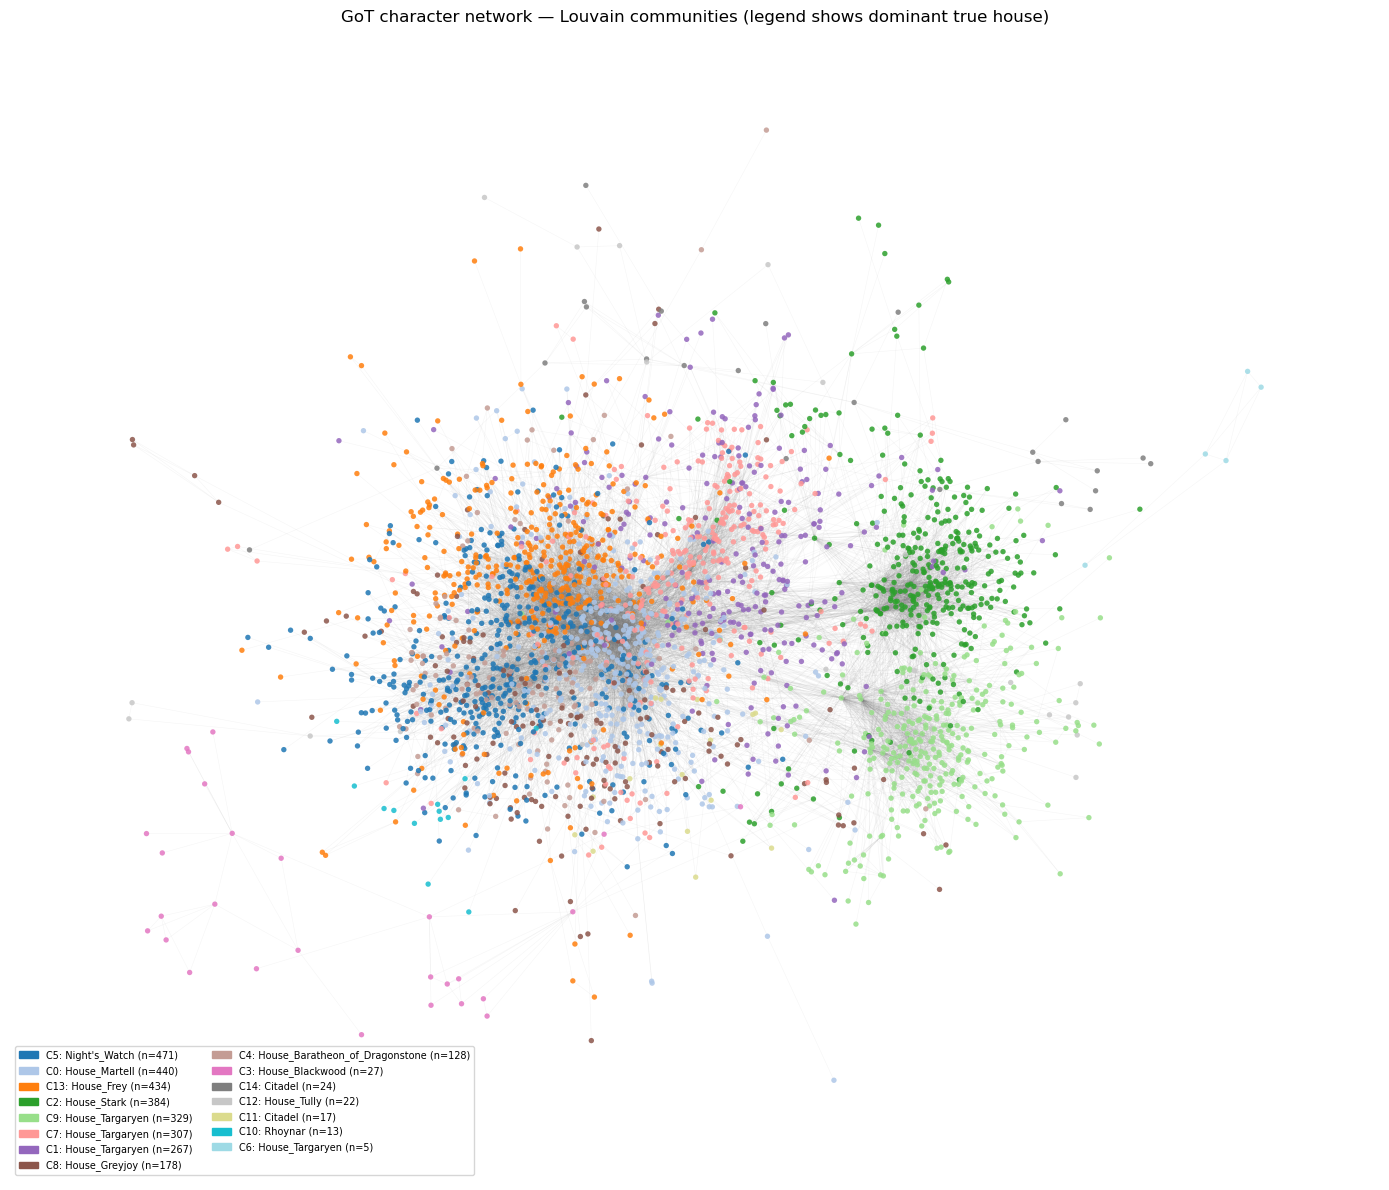

In [58]:
TOP_FOR_COLOR = 15
top_for_color = {c for c, _ in community_sizes.most_common(TOP_FOR_COLOR)}
cmap = cm.get_cmap('tab20', TOP_FOR_COLOR)
color_lookup = {c: cmap(i) for i, c in enumerate(sorted(top_for_color, key=lambda x: -community_sizes[x]))}

node_colors = [color_lookup.get(partition[n], (0.85, 0.85, 0.85, 0.6)) for n in LCC.nodes()]

pos = nx.spring_layout(LCC, seed=42, k=0.15, iterations=40)
fig, ax = plt.subplots(figsize=(14, 12))
nx.draw_networkx_edges(LCC, pos, alpha=0.08, edge_color='gray', width=0.4, ax=ax)
nx.draw_networkx_nodes(LCC, pos, node_color=node_colors, node_size=15, alpha=0.85, linewidths=0, ax=ax)

patches = [
    mpatches.Patch(color=color_lookup[c], label=f'C{c}: {comm_summary.loc[comm_summary.community == c, "dominant_house"].values[0] if (comm_summary.community == c).any() else "?"} (n={community_sizes[c]})')
    for c in sorted(top_for_color, key=lambda x: -community_sizes[x])
]
ax.legend(handles=patches, loc='lower left', fontsize=7, ncol=2)
ax.set_title('GoT character network — Louvain communities (legend shows dominant true house)')
ax.axis('off')
plt.tight_layout()
plt.show()

## 10. Save the assignments



One row per character: their community, their primary house, the dominant house in their community, and a flag for whether the two agree. Easy to drop into the website later.

In [59]:
comm_dom_house = dict(zip(comm_summary['community'], comm_summary['dominant_house']))

out = pd.DataFrame([
    {
        'ID': n,
        'name': name_by_id.get(n, ''),
        'community': partition[n],
        'primary_house': primary_house.get(n, ''),
        'community_dominant_house': comm_dom_house.get(partition[n], ''),
    }
    for n in LCC.nodes()
])
out['agrees_with_community'] = (
    (out['primary_house'] != '') &
    (out['primary_house'] == out['community_dominant_house'])
)
out.to_csv('../csvs/community_vs_allegiance.csv', index=False)
print(f'Saved {len(out)} rows to community_vs_allegiance.csv')
out.head(10)

Saved 3046 rows to community_vs_allegiance.csv


,ID,name,community,primary_house,community_dominant_house,agrees_with_community
0,A_certain_man,A certain man,0,,House_Martell,False
1,Abelar_Hightower,Abelar Hightower,1,House_Hightower,House_Targaryen,False
2,Abelon,Abelon,2,Citadel,House_Stark,False
3,Addam_Frey,Addam Frey,1,House_Frey,House_Targaryen,False
4,Addam_Hightower,Addam Hightower,9,House_Hightower,House_Targaryen,False
5,Addam_Marbrand,Addam Marbrand,13,House_Marbrand,House_Frey,False
6,Addam_Osgrey,Addam Osgrey,1,House_Osgrey,House_Targaryen,False
7,Addam_Velaryon,Addam Velaryon,2,House_Velaryon,House_Stark,False
8,Addam_Whitehead,Addam Whitehead,0,House_Whitehead,House_Martell,False
9,Addison_Hill,Addison Hill,9,House_Swyft,House_Targaryen,False


In [60]:
# Communities with zero labelled members do not appear in comm_dom_house,
# so their members get agrees_with_community = False below. We report how many.
comms_without_labels = [c for c in community_sizes if c not in comm_dom_house]
if comms_without_labels:
    n_orphan_nodes = sum(community_sizes[c] for c in comms_without_labels)
    print(f'Note: {len(comms_without_labels)} communities ({n_orphan_nodes} nodes) have no characters with a known house \u2014 they are counted as non-agreeing in the headline below.')

labelled_out = out[out['primary_house'] != '']
agree_rate = labelled_out['agrees_with_community'].mean()
print(f'\nOf the {len(labelled_out)} characters with a known primary house,')
print(f'  {labelled_out["agrees_with_community"].sum()} ({agree_rate:.1%}) sit in a community whose dominant house matches their own.')



Of the 2598 characters with a known primary house,
  377 (14.5%) sit in a community whose dominant house matches their own.


## 11. Take-aways

* The modularity z-score in §3 tells us whether the network has *any* community structure at all.
* The ARI / NMI / V-measure in §5 quantify how much that community structure looks like the houses.
* The confusion matrix (§6) shows where the agreement is strong (one house dominates one community) and where it isn't (a single community absorbs many houses, or a single house is split across communities).
* The headline number at the end of §10 is the one-liner for the website: the share of named-house characters whose community is dominated by their own house.

### Caveats worth flagging in the report

* **Edges are co-mentions, not signed relationships.** The `affiliated` column is extracted from bios and does not distinguish ally from enemy. Two warring houses that constantly clash will be densely connected and may end up in the same community. A low agreement score therefore does not mean houses are irrelevant — it means narrative interactions cross house borders.
* **Louvain has a resolution limit.** Small houses (≲ 10 members) tend to get absorbed into larger communities. Numbers like ARI/NMI under-report agreement for the long tail of minor houses. Running Louvain at multiple `resolution` values, or trying Infomap/Leiden, would surface this.
* **Coverage gap.** Only nodes with a non-empty `allegiance` enter the agreement scores — the printout in §4 says how big a fraction that is. Characters without a house are still in the graph (and influence the community structure) but cannot be evaluated against a true label.
* **Some communities have no labelled members at all.** They are listed at the start of §10 and counted as non-agreeing in the headline number — a conservative choice.

### Possible follow-ups

* Run Louvain at multiple resolutions and watch ARI move with granularity.
* Compare Louvain to Infomap or Leiden to see whether the agreement rate is algorithm-specific.
* Map houses to regions (North, Reach, Westerlands, ...) and re-run — communities may match *region* better than *house* because rivals from the same region co-mention constantly.
* Restrict to nodes whose `affiliated` list has at least *k* entries — characters with one mention contribute almost no signal.
